In [1]:
# word2vec
# 推論ベースの手法とニューラルネットワーク
# カウントベースの手法の問題点
# 推論ベースの手法の概要
# ニューラルネットワークにおける単語の処理方法

In [3]:
# 全結合層による返還
import numpy as np

rng = np.random.default_rng()

c = np.array([[1, 0, 0, 0, 0, 0, 0]]) # 入力
W = rng.random((7, 3))                # 重み
h = c @ W                             # 中間ノード
print(h)

[[0.83956975 0.65320718 0.44902003]]


In [5]:
# MatMulレイヤの実装
import sys
sys.path.append("..")
from common.layers import MatMul

c = np.array([[1, 0, 0, 0, 0, 0, 0]])
W = rng.random((7, 3))
layer = MatMul(W)
h = layer.forward(c)
print(h)

[[0.82959655 0.69097331 0.9665133 ]]


In [6]:
# シンプルなword2vec
# CBOWモデルの推論処理
import sys
sys.path.append("..")
from common.layers import MatMul

# サンプルのコンテキストデータ
c0 = np.array([[1, 0, 0, 0, 0, 0, 0]])
c1 = np.array([[0, 0, 1, 0, 0, 0, 0]])

# 重みの初期化
W_in = rng.random((7, 3))
W_out = rng.random((3, 7))

# レイヤの生成
in_layer0 = MatMul(W_in)
in_layer1 = MatMul(W_in)
out_layer = MatMul(W_out)

# 順伝播
h0 = in_layer0.forward(c0)
h1 = in_layer1.forward(c1)
h = 0.5 * (h0 + h1)
s = out_layer.forward(h)

print(s)

[[0.82040484 0.93395256 0.93614891 0.74501856 0.77425556 0.94557125
  0.51948465]]


In [7]:
# CBOWモデルの学習
# word2vecの重みと分散表現
# コンテキストとターゲット

In [9]:
# コーパスのテキストを単語IDに変換する
import sys
sys.path.append("..")
from common.util import preprocess

text = "You say goodbye and I say hello."
corpus, word_to_id, id_to_word = preprocess(text)
print(corpus)
print()
print(id_to_word)

[0 1 2 3 4 1 5 6]

{0: 'you', 1: 'say', 2: 'goodbye', 3: 'and', 4: 'i', 5: 'hello', 6: '.'}


In [12]:
# コンテキストとターゲットを作成する関数を実装
def create_contexts_target(corpus, window_size=1):
    target = corpus[window_size:-window_size]
    contexts = []

    for idx in range(window_size, len(corpus)-window_size):
        cs = []
        for t in range(-window_size, window_size + 1):
            if t == 0:
                continue
            cs.append(corpus[idx + t])
        contexts.append(cs)

    return np.array(contexts), np.array(target)

contexts, target = create_contexts_target(corpus, window_size=1)
print(contexts)
print()
print(target)

[[0 2]
 [1 3]
 [2 4]
 [3 1]
 [4 5]
 [1 6]]

[1 2 3 4 1 5]


In [14]:
# one-hot表現への変換
import sys
sys.path.append("..")
from common.util import preprocess, create_contexts_target, convert_one_hot

text = "You say goodbye and I say hello."
corpus, word_to_id, id_to_word = preprocess(text)

contexts, target = create_contexts_target(corpus, window_size=1)

vocab_size = len(word_to_id)
target = convert_one_hot(target, vocab_size)
contexts = convert_one_hot(contexts, vocab_size)

In [15]:
print(contexts.shape)
print(target.shape)

(6, 2, 7)
(6, 7)


In [18]:
# CBOWモデルの実装
import sys
sys.path.append("..")
from common.layers import MatMul, SoftmaxWithLoss

class simpleCBOW:
    def __init__(self, vocab_size, hidden_size):
        V, H = vocab_size, hidden_size

        # 重みの初期化
        W_in = 0.01 * rng.random((V, H)).astype("f")
        W_out = 0.01 * rng.random((H, V)).astype("f")

        # レイヤの生成
        self.in_layer0 = MatMul(W_in)
        self.in_layer1 = MatMul(W_in)
        self.out_layer = MatMul(W_out)
        self.loss_layer = SoftmaxWithLoss()

        # 全ての重みと勾配をリストにまとめる
        layers = [self.in_layer0, self.in_layer1, self.out_layer]
        self.params, self.grads = [], []
        for layer in layers:
            self.params += layer.params
            self.grads += layer.grads
        
        # メンバ変数に単語の分散表現を設定
        self.word_vecs = W_in

    def forward(self, contexts, target):
        h0 = self.in_layer0.forward(contexts[:, 0])
        h1 = self.in_layer1.forward(contexts[:, 1])
        h = (h0 + h1) * 0.5
        score = self.out_layer.forward(h)
        loss = self.loss_layer.forward(score, target)
        return loss

    def backward(self, dout=1):
        ds = self.loss_layer.backward(dout)
        da = self.out_layer.backward(ds)
        da *= 0.5
        self.in_layer1.backward(da)
        self.in_layer0.backward(da)
        return None

| epoch 1 |  iter 1 / 2 | time 0[s] | loss 1.95
| epoch 2 |  iter 1 / 2 | time 0[s] | loss 1.95
| epoch 3 |  iter 1 / 2 | time 0[s] | loss 1.95
| epoch 4 |  iter 1 / 2 | time 0[s] | loss 1.95
| epoch 5 |  iter 1 / 2 | time 0[s] | loss 1.95
| epoch 6 |  iter 1 / 2 | time 0[s] | loss 1.95
| epoch 7 |  iter 1 / 2 | time 0[s] | loss 1.95
| epoch 8 |  iter 1 / 2 | time 0[s] | loss 1.95
| epoch 9 |  iter 1 / 2 | time 0[s] | loss 1.95
| epoch 10 |  iter 1 / 2 | time 0[s] | loss 1.94
| epoch 11 |  iter 1 / 2 | time 0[s] | loss 1.94
| epoch 12 |  iter 1 / 2 | time 0[s] | loss 1.94
| epoch 13 |  iter 1 / 2 | time 0[s] | loss 1.94
| epoch 14 |  iter 1 / 2 | time 0[s] | loss 1.94
| epoch 15 |  iter 1 / 2 | time 0[s] | loss 1.94
| epoch 16 |  iter 1 / 2 | time 0[s] | loss 1.94
| epoch 17 |  iter 1 / 2 | time 0[s] | loss 1.94
| epoch 18 |  iter 1 / 2 | time 0[s] | loss 1.94
| epoch 19 |  iter 1 / 2 | time 0[s] | loss 1.94
| epoch 20 |  iter 1 / 2 | time 0[s] | loss 1.94
| epoch 21 |  iter 1 / 2 | ti

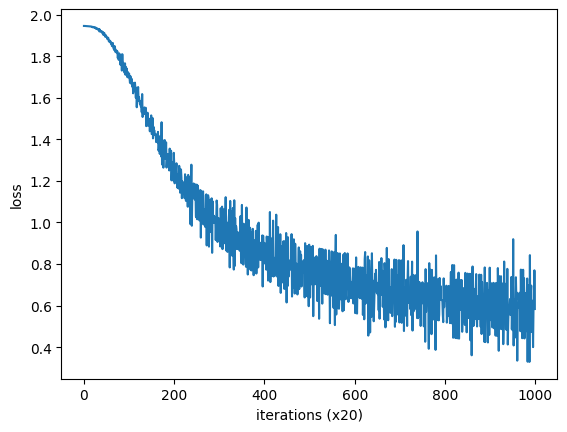

you [-1.1113298 -1.1924345  1.15092   -1.1751195 -1.1493412]
say [ 1.1846406   0.13228138 -1.1862503   1.2305541   1.2084969 ]
goodbye [-0.8251552  -0.8370001   0.6431926  -0.67191815 -0.7467765 ]
and [ 1.0058143   1.9202828  -0.97358316  1.0254323   1.0283006 ]
i [-0.82309526 -0.84817344  0.6466762  -0.6854211  -0.73725516]
hello [-1.1060468 -1.2031065  1.1734759 -1.1542073 -1.1240371]
. [ 1.0342791 -1.7180171 -1.1033081  1.037538   0.9962642]


In [22]:
# 学習コードの実装
import sys
sys.path.append("..")
from common.trainer import Trainer
from common.optimizer import Adam
from simple_cbow import SimpleCBOW
from common.util import preprocess, create_contexts_target, convert_one_hot

window_size = 1
hidden_size = 5
batch_size = 3
max_epoch = 1000

# 生のテキストをAIが読める「単語IDのリスト」に変換する
text = "You say goodbye and I say hello."
corpus, word_to_id, id_to_word = preprocess(text)

vocab_size - len(word_to_id)
# targetとcontextに分ける
contexts, target = create_contexts_target(corpus, window_size)
# 計算できる形に変換する（one-hot）
target = convert_one_hot(target, vocab_size)
contexts = convert_one_hot(contexts, vocab_size)

# 初期化
model = SimpleCBOW(vocab_size, hidden_size)
optimizer = Adam()
trainer = Trainer(model, optimizer)

# 学習開始
trainer.fit(contexts, target, max_epoch, batch_size)
trainer.plot()

word_vecs = model.word_vecs
for word_id, word in id_to_word.items():
    print(word, word_vecs[word_id])

In [23]:
# word2vecに関する補足
# CBOWモデルと確率
# skip-gramモデル
# coding: utf-8
import sys
sys.path.append('..')
from common.layers import MatMul, SoftmaxWithLoss


class SimpleSkipGram:
    def __init__(self, vocab_size, hidden_size):
        V, H = vocab_size, hidden_size

        # 重みの初期化
        W_in = 0.01 * np.random.randn(V, H).astype('f')
        W_out = 0.01 * np.random.randn(H, V).astype('f')

        # レイヤの生成
        self.in_layer = MatMul(W_in)
        self.out_layer = MatMul(W_out)
        self.loss_layer1 = SoftmaxWithLoss()
        self.loss_layer2 = SoftmaxWithLoss()

        # すべての重みと勾配をリストにまとめる
        layers = [self.in_layer, self.out_layer]
        self.params, self.grads = [], []
        for layer in layers:
            self.params += layer.params
            self.grads += layer.grads

        # メンバ変数に単語の分散表現を設定
        self.word_vecs = W_in

    def forward(self, contexts, target):
        h = self.in_layer.forward(target)
        s = self.out_layer.forward(h)
        l1 = self.loss_layer1.forward(s, contexts[:, 0])
        l2 = self.loss_layer2.forward(s, contexts[:, 1])
        loss = l1 + l2
        return loss

    def backward(self, dout=1):
        dl1 = self.loss_layer1.backward(dout)
        dl2 = self.loss_layer2.backward(dout)
        ds = dl1 + dl2
        dh = self.out_layer.backward(ds)
        self.in_layer.backward(dh)
        return None

In [ ]:
# カウントベース vs 推論ベース
